# Project Title: Customer Churn Analysis

**Created by:** Rahul Yadav  
**Role:** Aspiring Data Analyst  
**Skills:** Python | SQL | Pandas | NumPy | Matplotlib | Seaborn

## 1. Project Overview

- Customer Churn Analysis is a data analysis project that explores customer behavior and identifies the key factors that may lead to customer churn.
- The project uses Python, SQL, Pandas, NumPy, Matplotlib, and Seaborn to clean, analyze, and visualize customer data.


## 2. Business Problem

Customer churn is a major challenge for subscription-based businesses because losing customers can directly impact recurring revenue and customer lifetime value.

The objective of this analysis is to understand customer churn by analyzing customer demographics, subscription details, contract types, monthly charges, customer lifetime value (CLTV), and customer support interactions.

The analysis aims to identify patterns associated with customer churn and provide data-driven insights that can help businesses:

- Identify customers who are more likely to churn
- Understand factors associated with customer churn
- Analyze the revenue associated with churned customers
- Evaluate the relationship between customer support and churn
- Develop strategies to improve customer retention
- Reduce potential revenue loss caused by customer churn

## 3. Objectives

 Analyze customer churn patterns.
- Identify factors related to customer churn.
- Perform data cleaning and preprocessing.
- Explore customer demographics and service usage.
- Find important business insights.
- Create visualizations to understand churn behavior.
- Provide recommendations to reduce customer churn.

## 4. Dataset & Database Structure

The analysis is based on a customer churn database containing three related tables: **Customer**, **Subscription**, and **Support**.

### Database Tables

| Table | Rows | Description |
|---|---:|---|
| Customer | 600 | Customer demographic and basic information |
| Subscription | 600 | Subscription, plan, contract, charges, and churn-related information |
| Support | 1,000 | Customer support interactions, escalations, and CSAT information |

### 4.1 Customer Table

The Customer table contains customer demographic information such as:

- Customer ID
- Customer Name
- Country
- State
- Gender
- Date of Birth
- Interests
- Pincode

### 4.2 Subscription Table

The Subscription table contains subscription and churn-related information such as:

- Subscription ID
- Customer ID
- Subscription Start Date
- Subscription Type
- Renewal Date
- Plan Type
- Contract Type
- Cancellation Date
- Cancellation Reason
- Monthly Charges
- Customer Lifetime Value (CLTV)
- Churn Score

### 4.3 Support Table

The Support table contains customer support interaction information such as:

- Support ID
- Customer ID
- Complaint Date
- Escalations
- CSAT Score
- Col_1
- Customer Comments

### Database Relationship

The **Customer ID (`customerid`)** is used as the common key to integrate information from the three tables.

**Customer → Subscription → Support**

This integrated dataset is used for customer behavior analysis, churn analysis, revenue analysis, and customer support analysis.

## 5. Tools & Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SQL
- Jupyter Notebook
- PostgreSQL / SQLite


In [58]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os
import warnings
warnings.filterwarnings('ignore')

print("Import Libraries successfully!")

Import Libraries successfully!


## 6. Data Loading
   - Connect SQLite database
   - Load Customer table
   - Load Subscription table
   - Load Support table

In [59]:
conn = sqlite3.connect('customer_churn.db')

sql_query = """
        Select name
        from sqlite_master
        where  type = 'table'
        """
tables = pd.read_sql(sql_query,conn)
# create dataframe for each table

for table_name in tables['name']:
    df = pd.read_sql(f"Select * from {table_name}",conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [60]:
# print table names and columns names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name:{table_name}")
    # get columns information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query,conn)
    print("Columns:")
    print(columns['name'].tolist())
# Close connection
conn.close()


Table Name:db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name:db_subscription
Columns:
['subscription_id', 'customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name:db_support
Columns:
['support_id', 'customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [61]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,1824-AZJHH,Rakesh Iyer,India,Chandigarh,Male,1962-10-19,trekking,101338
1,9195-GYWYT,Kavita Pandey,India,Goa,Female,1979-12-16,travel,426542
2,5514-DCNDM,Jaya Malhotra,India,Karnataka,Female,1996-03-20,food blogging,561849
3,5925-UGYCB,Om Bhat,India,Delhi,Male,1975-11-20,reading,175255
4,4374-YXWCV,Varun Chopra,India,West Bengal,Male,1996-06-21,yoga,783503


In [62]:
df_db_subscription.head()

,subscription_id,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,601,1824-AZJHH,2025-06-03,Paid,2025-08-02,Premium,Monthly,None,None,42.02,3439.0,44
1,602,9195-GYWYT,2022-04-11,Referral,2022-05-11,Basic,Monthly,None,None,12.92,2136.0,35
2,603,5514-DCNDM,2021-06-13,Paid,2021-07-13,Standard,Monthly,2024-09-24,Too expensive,24.51,460.0,67
3,604,5925-UGYCB,2021-10-08,Referral,2021-11-07,Basic,Monthly,2023-02-24,Service issue,11.32,270.0,77
4,605,4374-YXWCV,2024-05-04,Trial,2024-10-31,Standard,Monthly,None,None,22.79,1122.0,50


In [63]:
df_db_support.head()

,support_id,customerid,complaint_date,escalations,csat_score,col_1,comment
0,1,1824-AZJHH,2026-06-02,N,25,None,Incorrect charges applied
1,2,1824-AZJHH,2026-06-24,N,87,None,General inquiry about plan
2,3,1824-AZJHH,2025-07-19,N,87,None,Unable to login to account
3,4,9195-GYWYT,2024-03-22,N,59,None,Slow response from support team
4,5,9195-GYWYT,2024-04-27,N,86,None,Account suspended without notice


## 7. Data Understanding
   - Shape
   - Columns
   - Data types
   - Missing values
   - Duplicates

In [64]:
print("Size of customer table: ",df_db_customer.shape)
print("Size of subscription table: ",df_db_subscription.shape)
print("Size of support table: ",df_db_support.shape)

Size of customer table:  (600, 8)
Size of subscription table:  (600, 12)
Size of support table:  (1000, 7)


In [65]:
print("Column names of customer table: ",df_db_customer.columns.tolist())
print("\nColumn names of subscription table: ",df_db_subscription.columns.tolist())
print("\nColumn names of support table: ",df_db_support.columns.tolist())


Column names of customer table:  ['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Column names of subscription table:  ['subscription_id', 'customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Column names of support table:  ['support_id', 'customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [66]:
print("Customer Table Information:")
df_db_customer.info()
print("***************************************************************************************")
print("\nSubscription Table Information:")
df_db_subscription.info()
print("***************************************************************************************")
print("\nSupport Table Information:")
df_db_support.info()

Customer Table Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  600 non-null    object
 1   name        600 non-null    object
 2   country     600 non-null    object
 3   state       600 non-null    object
 4   gender      600 non-null    object
 5   dob         600 non-null    object
 6   interests   572 non-null    object
 7   pincode     590 non-null    object
dtypes: object(8)
memory usage: 37.6+ KB
***************************************************************************************

Subscription Table Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   subscription_id          600 non-null    int64  
 1   customerid               600 non-n

In [67]:
print("Customer Table - Missing Values:")
customer_null = pd.DataFrame({
    'Missing Values': df_db_customer.isnull().sum(),
    'Missing %': (df_db_customer.isnull().mean() * 100).round(2)
})
print(customer_null)
print("***************************************************************************************")
print("\nSubscription Table - Missing Values:")
subscription_null = pd.DataFrame({
    'Missing Values': df_db_subscription.isnull().sum(),
    'Missing %': (df_db_subscription.isnull().mean() * 100).round(2)
})
print(subscription_null)
print("***************************************************************************************")
print("\nSupport Table - Missing Values:")
support_null = pd.DataFrame({
    'Missing Values': df_db_support.isnull().sum(),
    'Missing %': (df_db_support.isnull().mean() * 100).round(2)
})
print(support_null)

Customer Table - Missing Values:
            Missing Values  Missing %
customerid               0       0.00
name                     0       0.00
country                  0       0.00
state                    0       0.00
gender                   0       0.00
dob                      0       0.00
interests               28       4.67
pincode                 10       1.67
***************************************************************************************

Subscription Table - Missing Values:
                         Missing Values  Missing %
subscription_id                       0       0.00
customerid                            0       0.00
subscription_start_date               0       0.00
subscription_type                     0       0.00
renewal_date                          0       0.00
plan_type                             0       0.00
contract_type                         0       0.00
cancellation_date                   466      77.67
cancellation_reason                 466 

In [68]:
print("Customer Table - Duplicate Rows:")
print(df_db_customer.duplicated().sum())

print("\nSubscription Table - Duplicate Rows:")
print(df_db_subscription.duplicated().sum())

print("\nSupport Table - Duplicate Rows:")
print(df_db_support.duplicated().sum())

Customer Table - Duplicate Rows:
0

Subscription Table - Duplicate Rows:
0

Support Table - Duplicate Rows:
0


## 8. Data Cleaning
   - Customer table
   - Subscription table
   - Support table

##### Customer table

In [69]:
# 1) Rename columns name
df_db_customer.rename(columns={'name':'customer_name'},inplace = True)
# 2) Drop columns interest and pincode
df_db_customer.drop(columns=['interests','pincode'],inplace = True)
# Change of datatype of dob
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])
# Data standardization og gender
df_db_customer['gender']=df_db_customer['gender'].replace({'Men':'Male','Women':'Female'})
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     600 non-null    object        
 1   customer_name  600 non-null    object        
 2   country        600 non-null    object        
 3   state          600 non-null    object        
 4   gender         600 non-null    object        
 5   dob            600 non-null    datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 28.3+ KB


##### Subscription table

In [70]:
# chnage of datatypes
date_col = ['subscription_start_date','renewal_date','cancellation_date']
df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   subscription_id          600 non-null    int64         
 1   customerid               600 non-null    object        
 2   subscription_start_date  600 non-null    datetime64[ns]
 3   subscription_type        600 non-null    object        
 4   renewal_date             600 non-null    datetime64[ns]
 5   plan_type                600 non-null    object        
 6   contract_type            600 non-null    object        
 7   cancellation_date        134 non-null    datetime64[ns]
 8   cancellation_reason      134 non-null    object        
 9   monthly_charges          600 non-null    float64       
 10  cltv                     600 non-null    float64       
 11  churn_score              600 non-null    int64         
dtypes: datetime64[ns](3), float64(2), in

##### Support table

In [71]:
# Drop columns name col_1 and comment
df_db_support.drop(columns = ['col_1','comment'],inplace = True)
# change datatype
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   support_id      1000 non-null   int64         
 1   customerid      1000 non-null   object        
 2   complaint_date  1000 non-null   datetime64[ns]
 3   escalations     1000 non-null   object        
 4   csat_score      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 39.2+ KB


# 9. Data Integration

The customer, subscription, and support tables were integrated using `customerid` as the common key.

- Customer table → Customer demographic information
- Subscription table → Subscription and churn information
- Support table → Customer support interaction information

In [72]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep = 'last')

In [73]:
# Merge customer and subscription dataf
# Merge customer and subscription data
df = pd.merge(
    df_db_subscription,
    df_db_customer,
    on='customerid',
    how='left'
)

# Merge support data
df = pd.merge(
    df,
    df_db_support,
    on='customerid',
    how='left'
)

print("Integrated Dataset Shape:", df.shape)

Integrated Dataset Shape: (600, 21)


In [74]:
print("Integrated Dataset:")
display(df.head())

Integrated Dataset:


,subscription_id,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,...,churn_score,customer_name,country,state,gender,dob,support_id,complaint_date,escalations,csat_score
0,601,1824-AZJHH,2025-06-03,Paid,2025-08-02,Premium,Monthly,NaT,None,42.02,...,44,Rakesh Iyer,India,Chandigarh,Male,1962-10-19,2.0,2026-06-24,N,87.0
1,602,9195-GYWYT,2022-04-11,Referral,2022-05-11,Basic,Monthly,NaT,None,12.92,...,35,Kavita Pandey,India,Goa,Female,1979-12-16,7.0,2025-06-12,Y,95.0
2,603,5514-DCNDM,2021-06-13,Paid,2021-07-13,Standard,Monthly,2024-09-24,Too expensive,24.51,...,67,Jaya Malhotra,India,Karnataka,Female,1996-03-20,9.0,2023-10-07,Y,9.0
3,604,5925-UGYCB,2021-10-08,Referral,2021-11-07,Basic,Monthly,2023-02-24,Service issue,11.32,...,77,Om Bhat,India,Delhi,Male,1975-11-20,10.0,2023-02-23,Y,16.0
4,605,4374-YXWCV,2024-05-04,Trial,2024-10-31,Standard,Monthly,NaT,None,22.79,...,50,Varun Chopra,India,West Bengal,Male,1996-06-21,14.0,2026-04-20,N,74.0


In [75]:
print("Columns after integration:")
print(df.columns.tolist())

Columns after integration:
['subscription_id', 'customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score', 'customer_name', 'country', 'state', 'gender', 'dob', 'support_id', 'complaint_date', 'escalations', 'csat_score']


- Customers without support records are retained because the support table only contains recorded support interactions.

## 10. Feature Engineering
   - Churn Flag
   - Customer Age
   - Complaint Count
   - Churn Risk
   - Other useful features

In [76]:
# Create churn flag
df['churn_flag'] = np.where(
    df['cancellation_date'].notna(),
    1,
    0
)
#  1 → Customer churned
#  0 → Customer is active

In [77]:
# Create complaint Count
df['complaint_count'] = (
    df.groupby('customerid')['support_id']
      .transform('count')
)
df_db_support = (
    df_db_support
    .sort_values('complaint_date')
    .drop_duplicates('customerid', keep='last')
)


In [78]:
# Calculate customer age
today = pd.Timestamp.today()

df['age'] = (
    (df['subscription_start_date'] - df['dob']).dt.days / 365.25
).round().astype('Int64')

### Customer Age

- Customer age was calculated using the customer's date of birth and subscription start date to determine their age when they started the subscription.

In [79]:
# Calculate customer age group
df['age_group'] = pd.cut(
    df['age'],
    bins=[10, 20, 30, 40, 50, 60, 70],
    labels=['11-20', '21-30', '31-40', '41-50', '51-60', '61-70'],
    include_lowest=True
)
df['age_group'].value_counts().sort_index()

age_group
11-20     67
21-30    105
31-40    119
41-50    100
51-60    132
61-70     77
Name: count, dtype: int64

In [80]:
# Create churn_risk
df['churn_risk'] = np.select(
    [
        df['churn_score'] < 50,
        df['churn_score'].between(50, 69),
        df['churn_score'] >= 70
    ],
    [
        'Low',
        'Medium',
        'High'
    ],
    default='Unknown'
)
df['churn_risk'].value_counts()

churn_risk
Low       399
Medium    101
High      100
Name: count, dtype: int64

In [81]:
df.to_csv('churn_data_analysis.csv',index=False)

## 11. Exploratory Data Analysis (EDA)

## 11.1 Customer Analysis

### 11.1.1 Customer Distribution by State

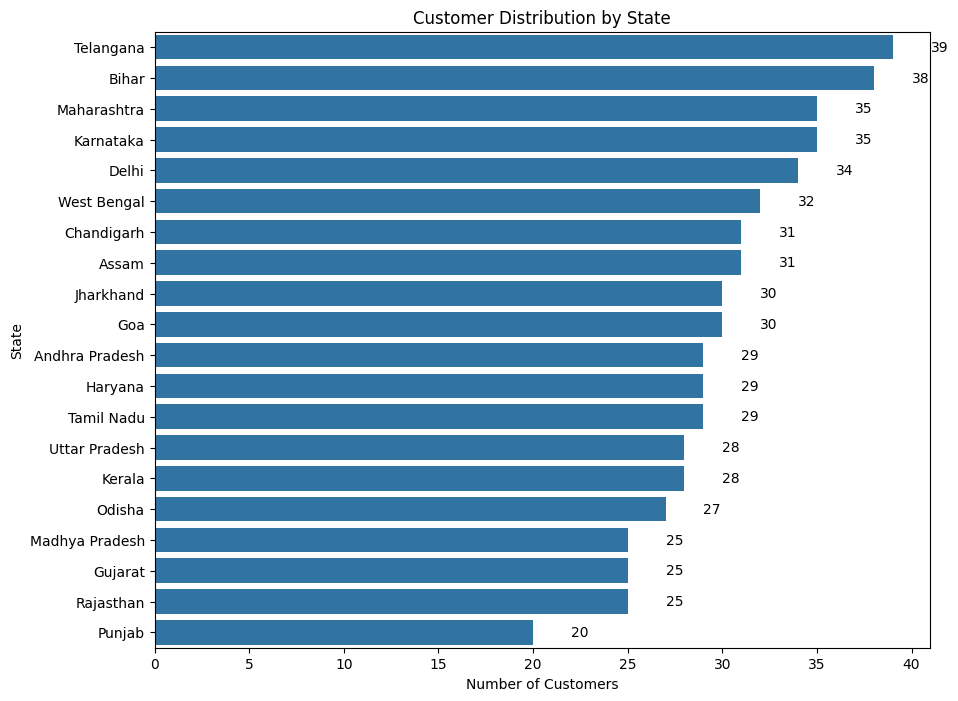

In [82]:
plt.figure(figsize=(10, 8))

bars = sns.countplot(
    data=df,
    y='state',
    order = df['state'].value_counts().index
    
)

for bar in bars.patches:
    count = int(bar.get_width())
    plt.text(
        count + 2,
        bar.get_y() + bar.get_height() / 2,
        count,
        va='center'
    )

plt.title('Customer Distribution by State')
plt.xlabel('Number of Customers')
plt.ylabel('State')
plt.show()

### Business Insight

- Customer distribution varies across different states.
- **Telangana has the highest number of customers**, while **Punjab has the lowest number of customers**.
- Most states have a relatively similar customer count, generally ranging between **20 and 39** customers.

### 11.1.2 Customer Distribution by Gender

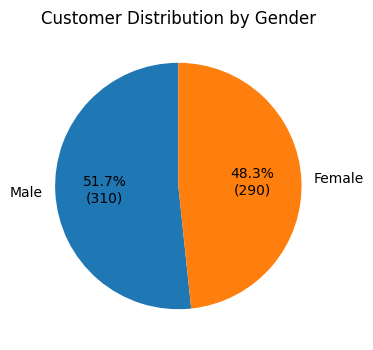

In [83]:
gender_count = df['gender'].value_counts()
plt.figure(figsize = (4,4))
plt.pie(
        gender_count.values,
        labels = gender_count.index,
        autopct = lambda p:f"{p:.1f}%\n({int(round(p*gender_count.sum()/100))})",
        startangle=90
)
plt.title("Customer Distribution by Gender")
plt.show()

### Business Insight

- The customer base is relatively balanced by gender, with **310 male customers (51.7%)** and **290 female customers (48.3%)**.
- Male customers represent a slightly larger share of the customer base than female customers.

### 11.1.3 Customer Distribution by Age Group

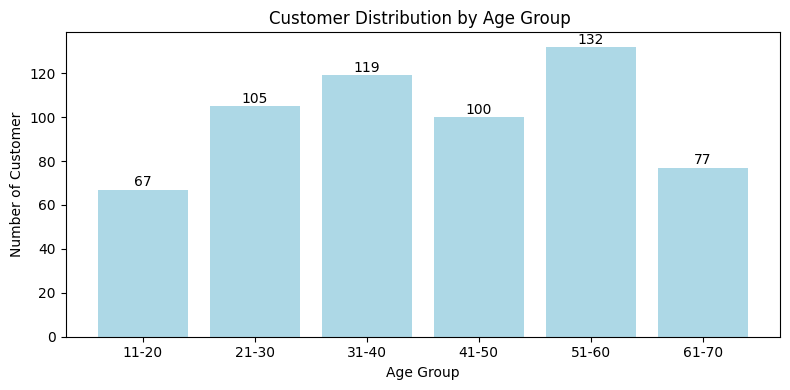

In [84]:
age_group_count = df['age_group'].value_counts().sort_index()


plt.figure(figsize=(8, 4))
bars = plt.bar(age_group_count.index,age_group_count.values,color="Lightblue")
plt.xlabel("Age Group")
plt.ylabel("Number of Customer")
plt.title("Customer Distribution by Age Group ")

# Show all subscription types count
plt.xticks(age_group_count.index, rotation=0)
# Count on top of each bar
for bar in bars:
    count = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count + 0.1,
        int(count),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Business Insight

- Customer distribution varies across different age groups.
- The **[51-60]** has the highest number of customers, while the **[11-20]** has the lowest number of customers.
- The distribution shows how the customer base is spread across different age segments.

### 11.1.4 Age Group vs Churn Rate

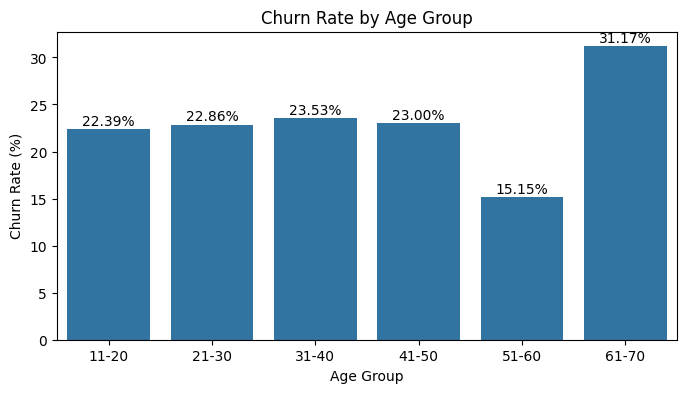

In [85]:
age_churn = (
    df.groupby('age_group', observed=True)['churn_flag']
      .mean()
      .mul(100)
      .round(2)
      .reset_index(name='churn_rate')
)

plt.figure(figsize=(8, 4))
bars = sns.barplot(
    data=age_churn,
    x='age_group',
    y='churn_rate'
)
for bar in bars.patches:
    count = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count + 0.1,
        f'{count:.2f}%',
        ha="center",
        va="bottom",
        fontsize=10
    )
plt.title('Churn Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')
plt.show()

### Business Insight

- Churn rates vary across different age groups.
- The **61–70** age group has the highest churn rate at **31.17%**.
- The **51–60** age group has the lowest churn rate at **15.15%**.
- The other age groups have relatively similar churn rates, ranging from **22.39%** to **23.53%**.

## 11.2 Subscription Analysis

### 11.2.1 Subscription Type Distribution

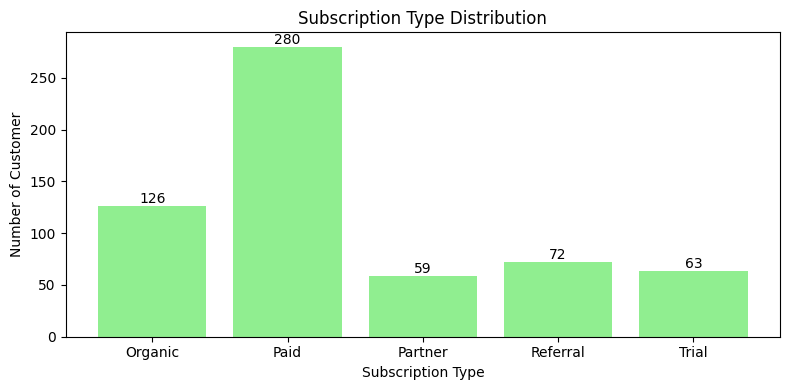

In [86]:
subscription = df['subscription_type'].value_counts().sort_index()
plt.figure(figsize=(8, 4))
bars = plt.bar(subscription.index,subscription.values,color="Lightgreen")
plt.xlabel("Subscription Type")
plt.ylabel("Number of Customer")
plt.title("Subscription Type Distribution")

# Show all subscription types count
plt.xticks(subscription.index, rotation=0)
# Count on top of each bar
for bar in bars:
    count = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count + 0.1,
        int(count),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Business Insight

- **Paid** is the most common subscription type, with **280 customers**.
- **Organic** has **126 customers**, followed by **Referral (72)** and **Trial (63)**.
- **Partner** has the lowest number of customers, with **59 customers**.
- The customer base is therefore primarily made up of **Paid subscriptions**.

### 11.2.2 Plan Type Distribution

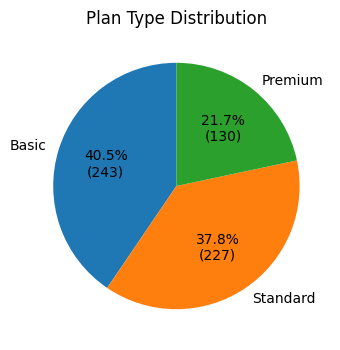

In [87]:
plan_type_count = df['plan_type'].value_counts()
plt.figure(figsize = (4,4))
plt.pie(
        plan_type_count.values,
        labels = plan_type_count.index,
        autopct = lambda p:f"{p:.1f}%\n({int(round(p*plan_type_count.sum()/100))})",
        startangle=90
)
plt.title("Plan Type Distribution")
plt.show()

### Business Insight

- **Basic** is the most common plan, with **243 customers (40.5%)**.
- **Standard** has **227 customers (37.8%)**, making it the second most common plan.
- **Premium** has the lowest customer share, with **130 customers (21.7%)**.
- Overall, **Basic and Standard plans account for most of the customer base**.

### 11.2.3 Contract Type Distribution

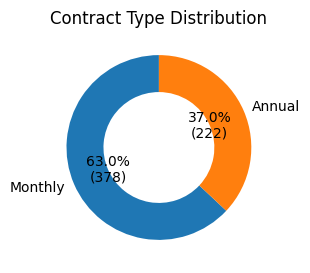

In [88]:
contract = df['contract_type'].value_counts()
plt.figure(figsize = (3,3))
plt.pie(
        contract.values,
        labels = contract.index,
        autopct = lambda p:f"{p:.1f}%\n({int(round(p*plan_type_count.sum()/100))})",
        startangle=90,
        wedgeprops=dict(width=0.4)
)
plt.title("Contract Type Distribution")
plt.show()


### Business Insight

- **Monthly contracts** account for the majority of customers, with **378 customers (63.0%)**.
- **Annual contracts** account for **222 customers (37.0%)**.
- The customer base is therefore more concentrated in **Monthly contracts** than Annual contracts.

### 11.2.4 Plan Type vs Churn Rate

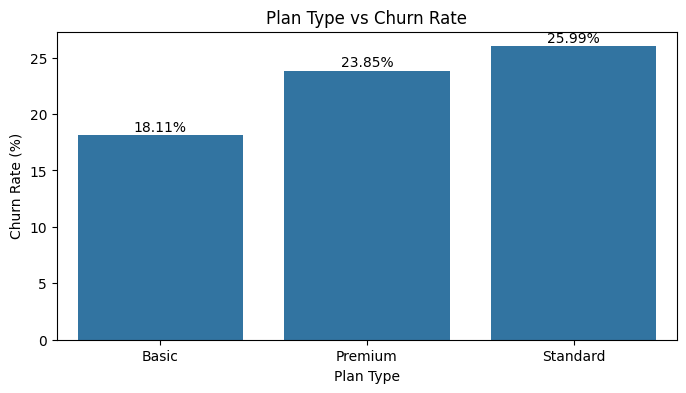

In [89]:
plan_churn = (
    df.groupby('plan_type', observed=True)['churn_flag']
      .mean()
      .mul(100)
      .round(2)
      .reset_index(name='churn_rate')
)
plan_churn
plt.figure(figsize=(8, 4))
bars = sns.barplot(
    data=plan_churn,
    x='plan_type',
    y='churn_rate'
)
for bar in bars.patches:
    count = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count + 0.1,
        f'{count:.2f}%',
        ha="center",
        va="bottom",
        fontsize=10
    )
plt.title('Plan Type vs Churn Rate')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')
plt.show()

### Business Insight

- Churn rates differ across the three plan types.
- **Standard** has the highest churn rate at **25.99%**.
- **Premium** has a churn rate of **23.85%**.
- **Basic** has the lowest churn rate at **18.11%**.

### 11.2.5 Contract Type vs Churn Rate

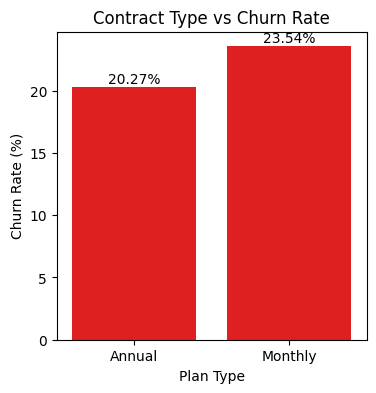

In [90]:
contract_churn = (
    df.groupby('contract_type', observed=True)['churn_flag']
      .mean()
      .mul(100)
      .round(2)
      .reset_index(name='churn_rate')
)
plan_churn
plt.figure(figsize=(4, 4))
bars = sns.barplot(
    data=contract_churn,
    x='contract_type',
    y='churn_rate',
    color='red'
)
for bar in bars.patches:
    count = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count + 0.1,
        f'{count:.2f}%',
        ha="center",
        va="bottom",
        fontsize=10
    )
plt.title('Contract Type vs Churn Rate')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')
plt.show()

### Business Insight

- Churn rates differ between the two contract types.
- Monthly contracts have a higher churn rate of **23.54%**.
- Annual contracts have a lower churn rate of **20.27%**.
- The difference in churn rate between Monthly and Annual contracts is **3.27 percentage points**.

### 11.2.6 Monthly Charges Analysis

In [91]:
print("Minimum Monthly Charges:", df['monthly_charges'].min())
print("Maximum Monthly Charges:", df['monthly_charges'].max())
print("Average Monthly Charges:", df['monthly_charges'].mean().round(2))
print("Median Monthly Charges:", df['monthly_charges'].median())

Minimum Monthly Charges: 5.99
Maximum Monthly Charges: 49.9
Average Monthly Charges: 19.41
Median Monthly Charges: 16.58


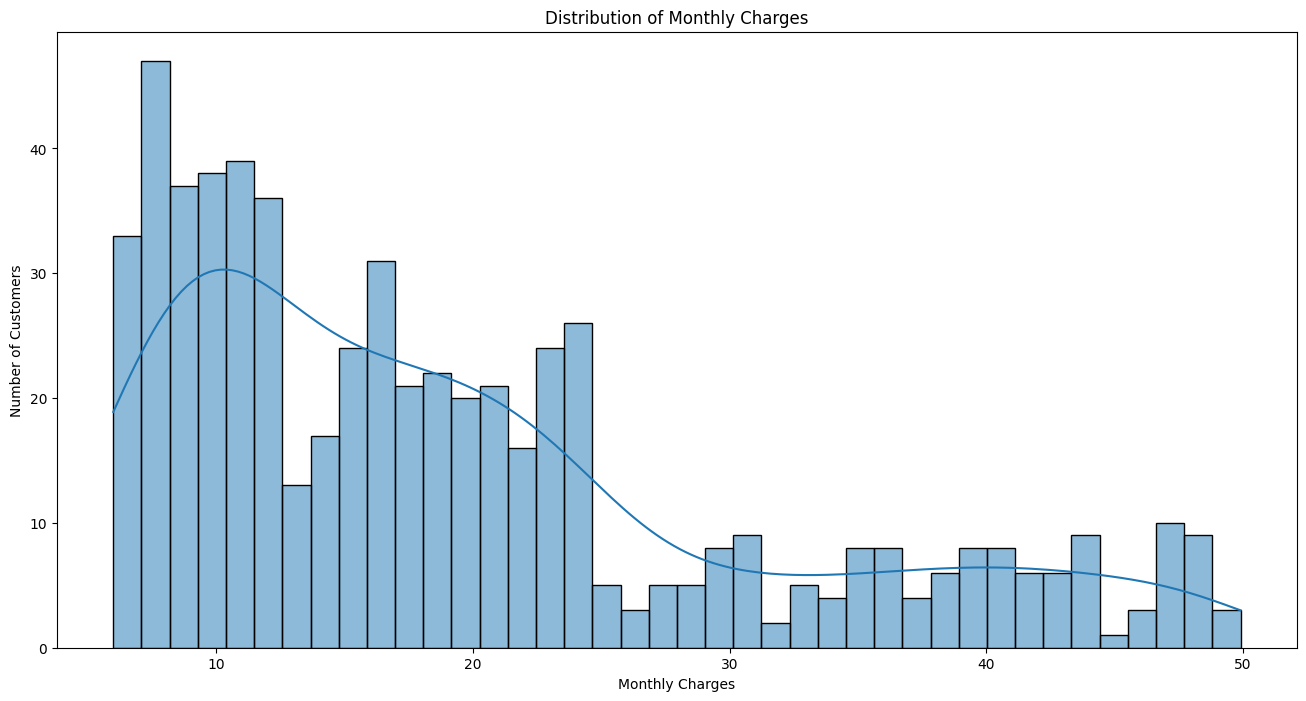

In [92]:
plt.figure(figsize=(16, 8))

sns.histplot(
    data=df,
    x='monthly_charges',
    bins=40,
    kde=True
)

plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.show()

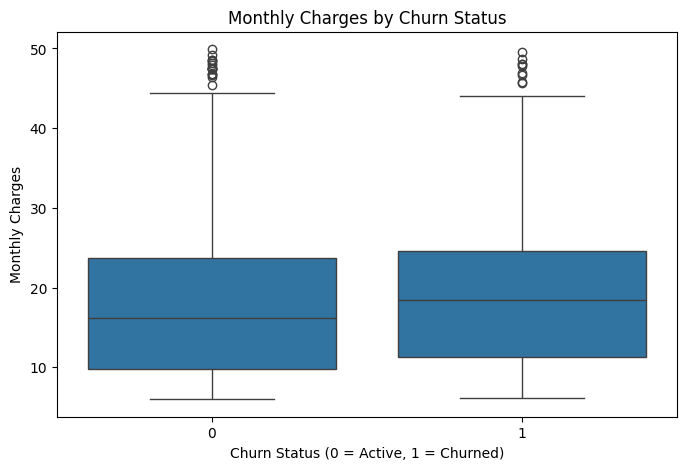

In [93]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='churn_flag',
    y='monthly_charges'
)

plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churn Status (0 = Active, 1 = Churned)')
plt.ylabel('Monthly Charges')
plt.show()

### Business Insight

- The distribution of monthly charges differs slightly between active and churned customers.
- **Churned customers have a slightly higher median monthly charge** than active customers.
- Both groups show a similar overall range of monthly charges, with some higher-value outliers.
- This suggests that monthly charges may differ somewhat by churn status, but the distributions also overlap considerably.

### 11.2.7 Customer Lifetime Value (CLTV) Analysis

In [94]:
print("Minimum CLTV:", df['cltv'].min())
print("Maximum CLTV:", df['cltv'].max())
print("Average CLTV:", df['cltv'].mean().round(2))
print("Median CLTV:", df['cltv'].median())

Minimum CLTV: 50.0
Maximum CLTV: 5961.0
Average CLTV: 2429.2
Median CLTV: 2228.5


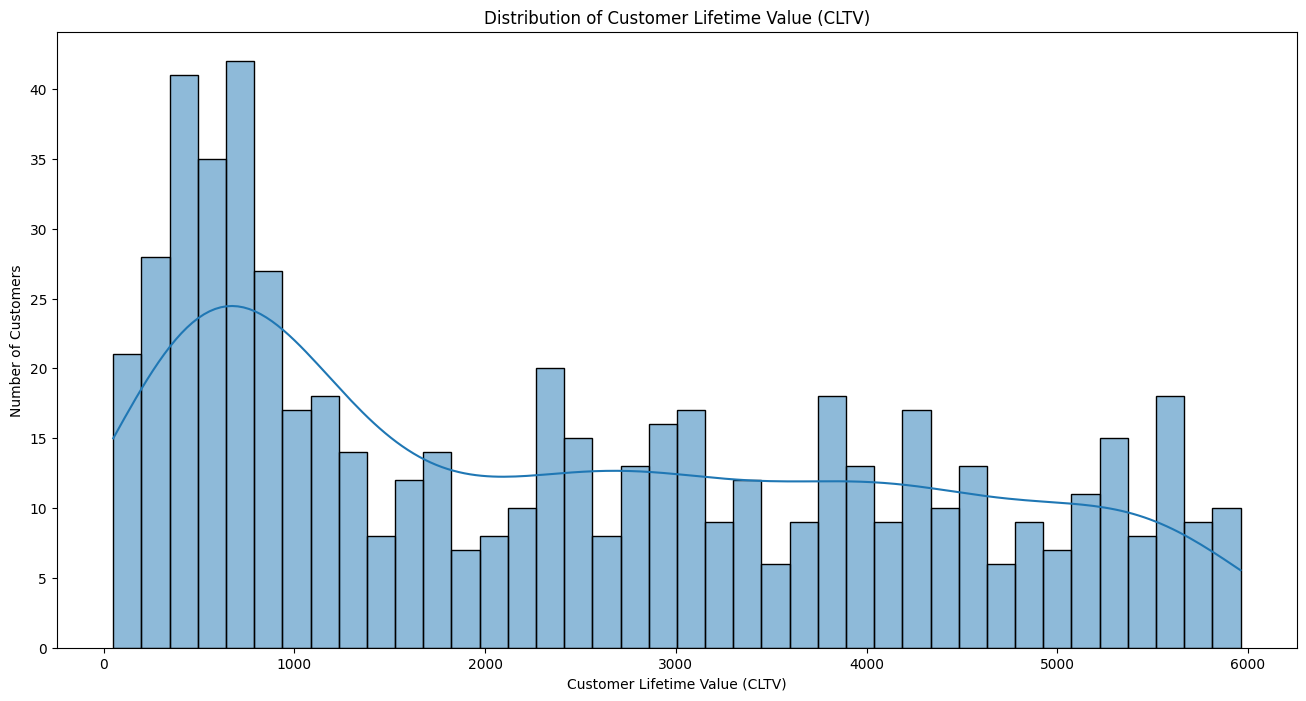

In [95]:
plt.figure(figsize=(16, 8))

sns.histplot(
    data=df,
    x='cltv',
    bins=40,
    kde=True
)

plt.title('Distribution of Customer Lifetime Value (CLTV)')
plt.xlabel('Customer Lifetime Value (CLTV)')
plt.ylabel('Number of Customers')

plt.show()

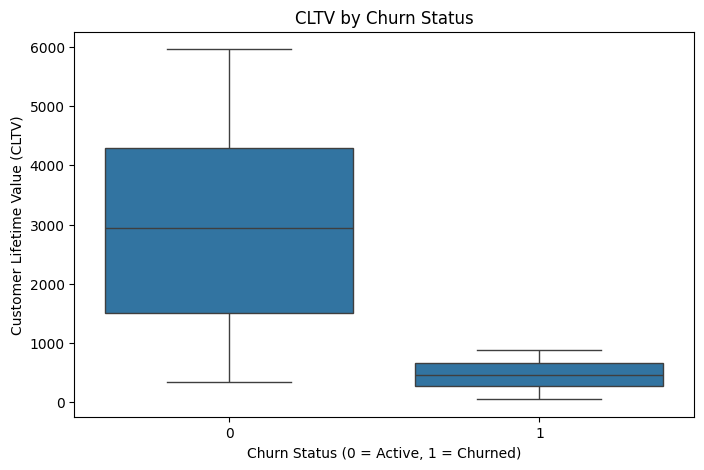

In [96]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='churn_flag',
    y='cltv'
)

plt.title('CLTV by Churn Status')
plt.xlabel('Churn Status (0 = Active, 1 = Churned)')
plt.ylabel('Customer Lifetime Value (CLTV)')

plt.show()

### Business Insight

- **Active customers have substantially higher CLTV values** compared with churned customers.
- The median CLTV of active customers is around **2,900**, while the median CLTV of churned customers is around **450**.
- Churned customers have a much narrower and lower CLTV distribution than active customers.
- This indicates that churned customers in this dataset generally have **lower customer lifetime value** than active customers.

## 11.3 Support Analysis

### 11.3.1 Complaint Count Distribution

In [97]:
df['complaint_count'].value_counts().reset_index(name ='Number of Complaints / Support Interactions')

,complaint_count,Number of Complaints / Support Interactions
0,1,404
1,0,196


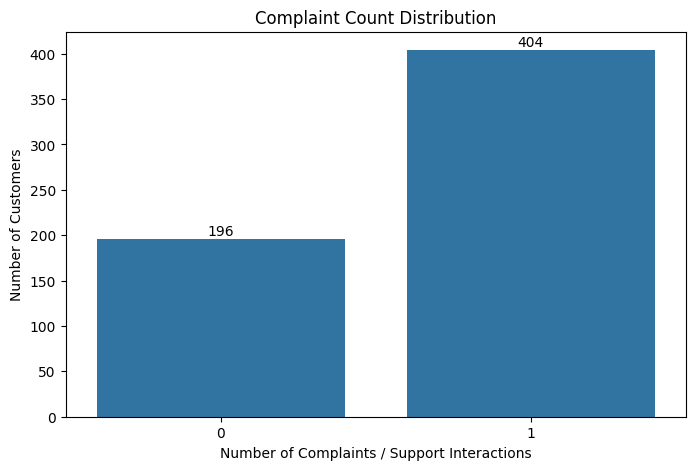

In [98]:
complaint_count = df['complaint_count'].value_counts()
plt.figure(figsize=(8, 5))

bars = sns.barplot(
    x=complaint_count.index,
    y=complaint_count.values
)

for bar in bars.patches:
    count = int(bar.get_height())
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count + 1,
        count,
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Complaint Count Distribution')
plt.xlabel('Number of Complaints / Support Interactions')
plt.ylabel('Number of Customers')

plt.show()

In [99]:
df['escalations'].value_counts().reset_index(name = 'Number of Customers')

,escalations,Number of Customers
0,N,305
1,Y,99


In [100]:
print("Minimum CSAT Score:", df['csat_score'].min())
print("Maximum CSAT Score:", df['csat_score'].max())
print("Average CSAT Score:", df['csat_score'].mean().round(2))
print("Median CSAT Score:", df['csat_score'].median())

Minimum CSAT Score: 0.0
Maximum CSAT Score: 100.0
Average CSAT Score: 48.43
Median CSAT Score: 46.0


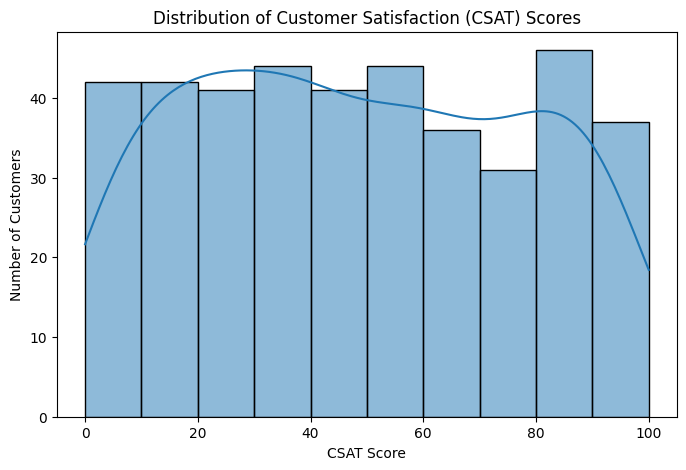

In [101]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='csat_score',
    bins=10,
    kde=True
)

plt.title('Distribution of Customer Satisfaction (CSAT) Scores')
plt.xlabel('CSAT Score')
plt.ylabel('Number of Customers')

plt.show()

### Business Insight

- CSAT scores are distributed across a wide range from **0 to 100**.
- The distribution is relatively spread out, with a large number of customers having CSAT scores across different score ranges.
- Higher CSAT scores, particularly around **80–90**, also have a substantial number of customers.
- Overall, customer satisfaction levels show **considerable variation** across the customer base.

In [102]:
csat_churn = (
    df.groupby('csat_score')['churn_flag']
      .mean()
      .mul(100)
      .round(2)
      .reset_index(name='churn_rate')
)


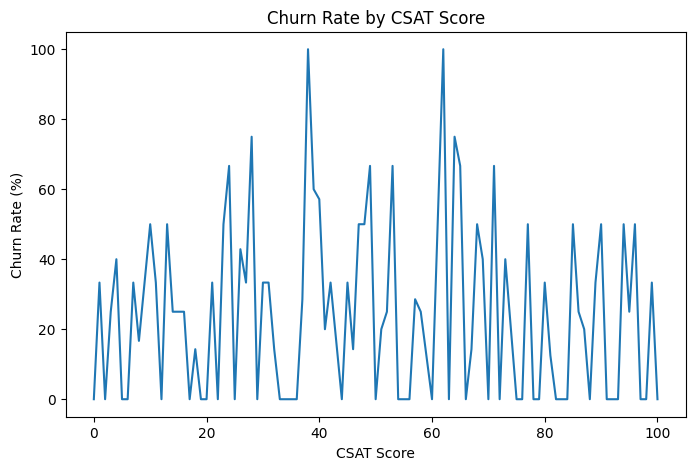

In [103]:
plt.figure(figsize=(8, 5))

bars = sns.lineplot(
    data=csat_churn,
    x='csat_score',
    y='churn_rate'
)

for bar in bars.patches:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.2,
        f'{value:.2f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Churn Rate by CSAT Score')
plt.xlabel('CSAT Score')
plt.ylabel('Churn Rate (%)')

plt.show()

### 11.3.2 Support Interaction vs Churn Rate

In [104]:
df['support_interaction'] = np.where(
    df['complaint_count'] > 0,
    'With Support',
    'Without Support'
)

In [105]:
support_churn = (
    df.groupby('support_interaction')['churn_flag']
      .mean()
      .mul(100)
      .round(2)
      .reset_index(name='churn_rate')
)

support_churn

,support_interaction,churn_rate
0,With Support,24.01
1,Without Support,18.88


### 11.3.3 Complaint Count vs Churn Rate

In [106]:
complaint_summary = (
    df.groupby('complaint_count')
      .agg(
          customer_count=('customerid', 'nunique'),
          churn_rate=('churn_flag', 'mean')
      )
      .reset_index()
)

complaint_summary['churn_rate'] = (
    complaint_summary['churn_rate'] * 100
).round(2)

complaint_summary

,complaint_count,customer_count,churn_rate
0,0,196,18.88
1,1,404,24.01


### Business Insight

- Customers with **1 recorded support interaction** have a higher churn rate of **24.01%**, compared with **18.88%** for customers with no recorded support interaction.
- The difference is **5.13 percentage points**.
- Most customers in the dataset (**404 out of 600**) have one recorded support interaction.

# 12. Churn Analysis

## 12.1 Overall Churn Rate

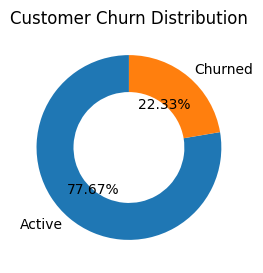

In [107]:
churn_counts = df['churn_flag'].value_counts()

plt.figure(figsize=(3, 3))

plt.pie(
    churn_counts,
    labels=['Active', 'Churned'],
    autopct='%1.2f%%',
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title('Customer Churn Distribution')
plt.show()

### Business Insight

- **22.33% of customers have churned**, while **77.67% remain active**.
- The majority of customers are still active, but more than one-fifth of the customer base has churned.
- This highlights the importance of monitoring churn patterns and understanding the factors associated with customer cancellations.

## 12.2 Churn by Gender

In [108]:
df.groupby('gender')['churn_flag'].value_counts().reset_index(name = 'churn_rate_per_gender')

,gender,churn_flag,churn_rate_per_gender
0,Female,0,227
1,Female,1,63
2,Male,0,239
3,Male,1,71


### Business Insight

- Churn rates are relatively similar between male and female customers.
- **Male customers have a churn rate of 22.90%**, while **female customers have a churn rate of 21.72%**.
- The difference is **1.18 percentage points**, indicating only a small difference in churn rates between the two groups.

## 12.3 Churn by State

In [109]:
churn_by_state = (df.groupby('state')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_per_state'))
churn_by_state

,state,churn_rate_per_state
0,Andhra Pradesh,17.24
1,Assam,29.03
2,Bihar,28.95
3,Chandigarh,29.03
4,Delhi,23.53
5,Goa,20.00
6,Gujarat,0.00
7,Haryana,20.69
8,Jharkhand,33.33
9,Karnataka,20.00


### Business Insight

- Churn rates vary across different states.
- **Jharkhand and Odisha have the highest churn rate at 33.33%**.
- **Gujarat has the lowest churn rate at 0.00%**.
- Rajasthan also has a relatively high churn rate of **32.00%**, while Punjab has a lower churn rate of **10.00%**.
- The variation in state-wise churn rates shows that churn differs across geographic customer segments.

# 13. Revenue Analysis

## 13.1 Revenue by State

In [110]:
churn_by_state = (df.groupby('state')['monthly_charges'].sum().reset_index(name = 'monthly_charges_per_state'))
churn_by_state.sort_values(by = 'monthly_charges_per_state',ascending = False).reset_index(drop=True)

,state,monthly_charges_per_state
0,Telangana,773.37
1,Andhra Pradesh,719.34
2,West Bengal,702.16
3,Delhi,694.08
4,Assam,690.72
5,Bihar,654.86
6,Chandigarh,651.25
7,Karnataka,636.27
8,Goa,601.01
9,Haryana,570.90


## 13.2 Revenue at Risk

In [111]:
total_revenue = df['monthly_charges'].sum()

revenue_at_risk = df.loc[
    df['churn_flag'] == 1,
    'monthly_charges'
].sum()

revenue_at_risk_percentage = (
    revenue_at_risk / total_revenue * 100
)

print("Total Monthly Revenue:", round(total_revenue, 2))
print("Revenue at Risk:", round(revenue_at_risk, 2))
print("Revenue at Risk (%):", round(revenue_at_risk_percentage, 2))

Total Monthly Revenue: 11643.95
Revenue at Risk: 2778.29
Revenue at Risk (%): 23.86


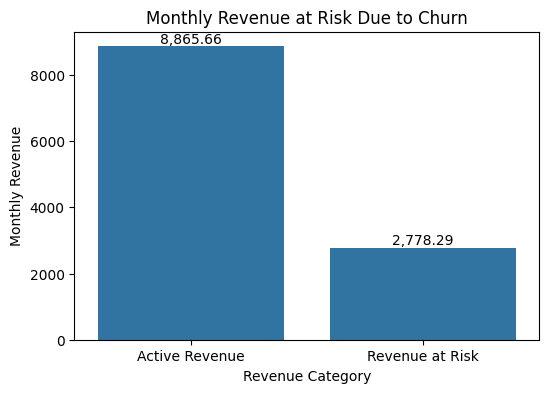

In [112]:
revenue_summary = pd.DataFrame({
    'Revenue Type': ['Active Revenue', 'Revenue at Risk'],
    'Revenue': [
        df.loc[df['churn_flag'] == 0, 'monthly_charges'].sum(),
        df.loc[df['churn_flag'] == 1, 'monthly_charges'].sum()
    ]
})

plt.figure(figsize=(6, 4))

bars = sns.barplot(
    data=revenue_summary,
    x='Revenue Type',
    y='Revenue'
)

for bar in bars.patches:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f'{value:,.2f}',
        ha='center',
        va='bottom'
    )

plt.title('Monthly Revenue at Risk Due to Churn')
plt.xlabel('Revenue Category')
plt.ylabel('Monthly Revenue')
plt.show()

### Business Insight 
- Active Revenue: **8,865.66**
- Revenue at Risk: **2,778.29**
- Revenue at Risk: approximately **23.9%** of total monthly revenue.

# 14. Time-Based Churn Analysis

In [113]:
df['cancellation_month'] = (
    df['cancellation_date']
    .dt.to_period('M')
    .astype(str)
)

In [114]:
monthly_churn = (
    df[df['churn_flag'] == 1]
    .groupby('cancellation_month')
    .size()
    .reset_index(name='churned_customers')
)

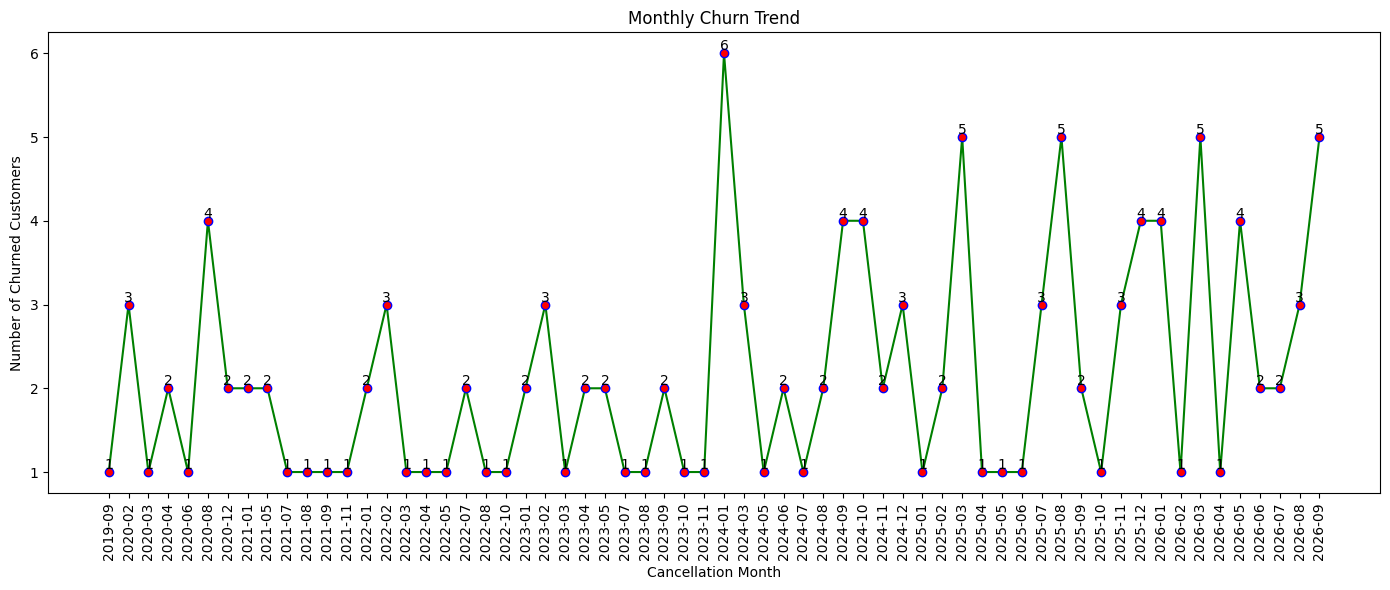

In [115]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_churn['cancellation_month'],
    monthly_churn['churned_customers'],
    marker='o',
    color = 'green',
    markerfacecolor='red',
    markeredgecolor='blue'
)

for x, y in zip(
    monthly_churn['cancellation_month'],
    monthly_churn['churned_customers']
):
    plt.text(x, y, str(y), ha='center', va='bottom')

plt.title('Monthly Churn Trend')
plt.xlabel('Cancellation Month')
plt.ylabel('Number of Churned Customers')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Business Insight 
- Monthly churn fluctuates between 1 and 6 customers.
- The highest churn was 6 customers in one month.
- Several months recorded 5 churned customers, showing periodic spikes in cancellations.
- Overall, churn varies over time rather than remaining constant.

In [116]:
highest_churn_month = monthly_churn.loc[
    monthly_churn['churned_customers'].idxmax()
]

lowest_churn_month = monthly_churn.loc[
    monthly_churn['churned_customers'].idxmin()
]

print("Highest Churn Month:")
print(highest_churn_month)

print("\nLowest Churn Month:")
print(lowest_churn_month)

Highest Churn Month:
cancellation_month    2024-01
churned_customers           6
Name: 31, dtype: object

Lowest Churn Month:
cancellation_month    2019-09
churned_customers           1
Name: 0, dtype: object


# 15. Key Business Insights

Based on the exploratory data analysis and churn analysis, the following key business insights were identified:

### 1. Overall Customer Churn

- **22.33%** of customers have churned, while **77.67%** remain active.

### 2. Plan Type and Churn

- **Standard plan** has the highest churn rate at **25.99%**.
- **Premium:** 23.85%
- **Basic:** 18.11%

### 3. Contract Type and Churn

- **Monthly contracts** have a higher churn rate of **23.54%**.
- **Annual contracts:** 20.27%.

### 4. Age Group and Churn

- The **61–70** age group has the highest churn rate at **31.17%**.
- The **51–60** age group has the lowest at **15.15%**.
- Other age groups range from **22.39% to 23.53%**.

### 5. Gender and Churn

- Churn rates are similar between genders.
- **Male:** 22.90%
- **Female:** 21.72%

### 6. State-wise Churn

- Churn rates vary across states.
- **Jharkhand and Odisha:** highest at **33.33%**.
- **Gujarat:** lowest at **0%**.

### 7. Customer Support and Churn

- Customers with **1 recorded support interaction** have a churn rate of **24.01%**.
- Customers with **no recorded support interaction** have a churn rate of **18.88%**.
- The difference is **5.13 percentage points**.

### 8. Revenue at Risk

- **₹2,778.29** of monthly revenue is associated with churned customers.
- This represents approximately **23.9%** of total monthly revenue.

### 9. Monthly Churn Trend

- Monthly churn fluctuates between **1 and 6 customers**.
- Several months show spikes of **5–6 churned customers**.

### 10. Customer Base Distribution

- **Basic plan:** 243 customers (40.5%)
- **Standard plan:** 227 customers (37.8%)
- **Premium plan:** 130 customers (21.7%)
- Basic and Standard plans together represent most of the customer base.

### Overall Insight

> The analysis shows that customer churn varies across **plan type, contract type, age group, state, and customer support interactions**, while churned customers also represent a measurable portion of monthly revenue at risk.


# 16. Business Recommendations

Based on the churn analysis and identified business insights, the following recommendations can help improve customer retention and reduce potential revenue loss:

### 1. Focus on High-Churn Segments

- Monitor customers in the **Standard plan**, which has a churn rate of **25.99%**.
- Pay attention to the **61–70 age group**, which has a churn rate of **31.17%**.
- Investigate states with higher observed churn rates, such as **Jharkhand and Odisha**.

### 2. Monitor Monthly Contracts

- Monthly contracts have a churn rate of **23.54%**, compared with **20.27%** for annual contracts.
- Analyze the reasons for higher churn among monthly-contract customers.

### 3. Improve Customer Support

- Customers with **1 recorded support interaction** have a higher observed churn rate (**24.01%**) than customers with no recorded support interaction (**18.88%**).
- Review recurring customer issues and support interactions to identify areas for service improvement.

### 4. Monitor Revenue at Risk

- Track the **₹2,778.29 monthly revenue** associated with churned customers.
- Monitor high-value customers using **monthly charges and CLTV** to understand potential revenue impact.

### 5. Monitor Churn Trends

- Track monthly churn regularly because churn fluctuates between **1 and 6 customers**.
- Investigate months with higher cancellation counts to understand possible contributing factors.

### 6. Use Churn Risk for Monitoring

- Use the existing **churn score and churn risk categories** to identify customers who may require additional monitoring.
- Compare predicted risk with actual churn to evaluate the usefulness of the risk score.

### 7. Build a Churn Monitoring Dashboard

Track key KPIs such as:

- Churn Rate
- Active Customers
- Churned Customers
- Revenue at Risk
- Monthly Churn
- Monthly Charges
- CLTV
- Support Interactions
- CSAT Score
- Churn Risk

### Overall Recommendation

> Regularly monitor **high-churn customer segments, contract types, support interactions, churn trends, and revenue at risk** to support data-driven customer retention strategies.

# 17. Conclusion

This customer churn analysis provided a data-driven understanding of customer churn patterns using customer, subscription, and support data.

The analysis identified key churn patterns across **plan type, contract type, age group, gender, state, and customer support interactions**. Overall, **22.33% of customers have churned**, while **77.67% remain active**.

The analysis also estimated **₹2,778.29 in monthly revenue associated with churned customers**, highlighting the potential financial impact of customer churn.

The findings can help businesses monitor high-churn segments, understand customer behavior, improve customer support, and track revenue at risk.

Overall, this project demonstrates the use of **SQL, Python, Pandas, NumPy, Matplotlib, and Seaborn** to transform customer data into meaningful business insights and actionable recommendations.